In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_raw = pd.read_csv('sri_lanka_irrigation_dataset.csv') 
print(f"Shape: {dataset_raw.shape} → {dataset_raw.shape[0]} records, {dataset_raw.shape[1]} features") 
pd.set_option('display.max_columns', None) 
dataset_raw.head()

Shape: (10000, 28) → 10000 records, 28 features


,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm,Gross_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,13.2,3.77,0.70,0.0,NaN
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,0.0,3.87,0.90,0.0,NaN
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,0.0,2.79,1.05,0.0,NaN
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,0.0,3.09,0.75,0.0,NaN
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,62.4,4.43,1.05,2.8,3.1


# We drop these columns because they are not necessary to predict the Net Irrigation Requirement (mm).

In [3]:
# Drop both the target variable and the ID column at the start
df_raw = dataset_raw.drop(["Gross_Irrigation_Requirement_mm", "Previous_Irrigation_mm"], axis=1)

# Here We inspect the dataset at this stage to detect "dirty" (inconsistent/corrupted) entries and identify any null (missing) values across all columns.

In [4]:
df_raw

,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70,0.0
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90,0.0
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05,0.0
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75,0.0
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2498,Nuwara Eliya,Wet,Maha,Chili,Late-season,30,Clay,6.94,30.48,1.01,1.02,26.3,22.8,24.6,83.3,189.4,6.3,8.6,Furrow/Surface,Rainfed,0.59,No,2.55,0.90,0.0
9996,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Initial,20,Sandy,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,Drip,Minor Tank,0.59,No,4.84,1.05,38.6
9997,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Development,30,Sandy,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,Drip,Minor Tank,0.59,No,5.27,1.10,140.4
9998,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Mid-season,40,Sandy,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,Drip,Minor Tank,0.59,No,5.37,1.20,119.2


In [5]:
# ── 3B. Column-level quality overview ──────────────────────────────────────
def scan_data_quality(df):
    hidden_numeric, dirty_categorical = [], []
    for col in df.select_dtypes(include=['object', 'string']).columns:
        vals = df[col].dropna().unique()
        if vals.size == 0: continue
        
        if pd.to_numeric(pd.Series(vals), errors='coerce').notna().mean() > 0.5 and df[col].nunique() != len(df):
            hidden_numeric.append(col)
        elif vals.size != pd.Series(vals).astype(str).str.strip().nunique():
            dirty_categorical.append(col)
    return hidden_numeric, dirty_categorical

hidden_numeric_cols, dirty_cols_names = scan_data_quality(df_raw)

# Generate Quality Table
col_info = pd.DataFrame({
    'pandas_dtype' : df_raw.dtypes.astype(str),
    'null_count'   : df_raw.isna().sum(),
    'null_%'       : (df_raw.isna().mean() * 100).round(2),
    'n_unique'     : df_raw.nunique(),
    'sample_values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
}).sort_values('null_%', ascending=False)

print("=== Column Quality Scan ===")
# Inline Row Styling based on row index name
display(col_info.style.apply(lambda row: 
    ['background-color: #ffe6e6'] * len(row) if row.name in hidden_numeric_cols else 
    ['background-color: #fff2cc'] * len(row) if row.name in dirty_cols_names else 
    [''] * len(row), axis=1))

if hidden_numeric_cols: print(f"• Hidden Numeric Columns (Red): {hidden_numeric_cols}")
if dirty_cols_names: print(f"• Dirty Categorical Columns (Yellow): {dirty_cols_names}")
if not hidden_numeric_cols and not dirty_cols_names:print(f"Wrong data types and dirty entries have been corrected.\n")

=== Column Quality Scan ===


,pandas_dtype,null_count,null_%,n_unique,sample_values
Field_Cycle_ID,int64,0,0.000000,2500,"[0, 1, 2]"
District,object,0,0.000000,25,"['Kalutara', 'Monaragala', 'Galle']"
Climate_Zone,object,0,0.000000,3,"['Wet', 'Intermediate', 'Dry']"
Season,object,0,0.000000,2,"['Maha', 'Yala']"
Crop_Type,object,0,0.000000,6,"['Big Onion', 'Paddy (Rice)', 'Tomato']"
Crop_Growth_Stage,object,0,0.000000,4,"['Initial', 'Development', 'Mid-season']"
Stage_Duration_days,int64,0,0.000000,11,"[15, 25, 35]"
Soil_Type,object,0,0.000000,4,"['Sandy Loam', 'Sandy', 'Loamy']"
Soil_pH,float64,0,0.000000,350,"[5.95, 5.77, 5.9]"
Soil_Moisture_pct,float64,0,0.000000,2867,"[15.2, 18.5, 18.9]"


Wrong data types and dirty entries have been corrected.



# The 'District' column is removed for two main reasons.

## 1.The specific environmental factors influenced by geography—such as climate, soil type, and rainfall—are already captured as precise, individual features. This makes the regional label redundant.

## 2. 'District' is a categorical variable with 25 unique values. Encoding it would introduce 25 new features, unnecessarily increasing dataset dimensionality and model complexity."

In [6]:
df_raw = df_raw.drop(["District"], axis=1, errors='ignore')

# I am doing this step bacuse to make sure the feature crops Coefficient (Kc) has the informations of  the featueres Crop_Type and Crop_Growth_Stage

In [7]:
# Create a pivot table showing the average, min, and max Kc values 
# broken down by each crop type and its specific growth stage
kc_profile = dataset_raw.groupby(['Crop_Type', 'Crop_Growth_Stage'])['Crop_Coefficient_Kc'].agg(
    Mean_Kc='mean',
    Min_Kc='min',
    Max_Kc='max',
    Record_Count='count'
).reset_index()

# Sort logically to keep crop lifecycle stages cohesive
print("--- Crop Coefficient (Kc) Breakdown by Growth Stage ---")
print(kc_profile.to_string(index=False))

--- Crop Coefficient (Kc) Breakdown by Growth Stage ---
   Crop_Type Crop_Growth_Stage  Mean_Kc  Min_Kc  Max_Kc  Record_Count
   Big Onion       Development     0.90    0.90    0.90           428
   Big Onion           Initial     0.70    0.70    0.70           428
   Big Onion       Late-season     0.75    0.75    0.75           428
   Big Onion        Mid-season     1.05    1.05    1.05           428
       Chili       Development     0.85    0.85    0.85           400
       Chili           Initial     0.60    0.60    0.60           400
       Chili       Late-season     0.90    0.90    0.90           400
       Chili        Mid-season     1.05    1.05    1.05           400
  Green Gram       Development     0.75    0.75    0.75           435
  Green Gram           Initial     0.40    0.40    0.40           435
  Green Gram       Late-season     0.40    0.40    0.40           435
  Green Gram        Mid-season     1.05    1.05    1.05           435
       Maize       Development    

In [8]:
df=df_raw.copy()

# Removing the Duplicate by rows and columns

In [9]:
print("--- Checking for Duplicate Rows ---")
duplicate_row_count = df.duplicated().sum()

if duplicate_row_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"✓ Removed {duplicate_row_count} duplicate rows.")
else:
    print("✓ Clean! No duplicate rows detected.")

print(f"Current Shape: {df.shape[0]} rows, {df.shape[1]} features\n")


# --- 2. Lightning-Fast Duplicate Column Investigation ---
print("--- Investigating Duplicate Columns ---")

# Vectorized transpose detection finds identical columns in C-speed, not Python loops
is_duplicate_col = df.T.duplicated(keep='first')

if is_duplicate_col.any():
    # Grab the names of the duplicate columns to be removed
    duplicate_cols = df.columns[is_duplicate_col].tolist()
    print(f"⚠ Found {len(duplicate_cols)} identical duplicate column(s): {duplicate_cols}")
    
    # Optional: Map duplicates to their original columns for clear logging
    for col in duplicate_cols:
        # Find the first column in the dataframe that matches this duplicate column perfectly
        original = df.columns[(df.T == df[col]).all(axis=1)][0]
        print(f"  • Column '{col}' is an identical twin of original column: '{original}'")
        
    print("\nℹ Action: No columns were deleted yet. Please review the twins listed above.")
else:
    print("✓ Clean! No duplicate columns detected.")

print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} features\n")




--- Checking for Duplicate Rows ---
✓ Clean! No duplicate rows detected.
Current Shape: 10000 rows, 25 features

--- Investigating Duplicate Columns ---
✓ Clean! No duplicate columns detected.
Final Shape: 10000 rows, 25 features



# Splitting the Input featues and Target featute

In [10]:
X = df.drop(columns=['Net_Irrigation_Requirement_mm'])
y = df['Net_Irrigation_Requirement_mm']
print(f"Features matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Features matrix X: (10000, 24)
Target vector  y: (10000,)


# Splitting the dataset based on group

In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=df['Field_Cycle_ID']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"\nTrain Target Mean: {y_train.mean():.2f}")
print(f"Test Target Mean : {y_test.mean():.2f}")

Training Set : 8000 records
Testing Set  : 2000 records

Train Target Mean: 22.48
Test Target Mean : 23.65


In [12]:
X_train

,Field_Cycle_ID,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc
0,0,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70
1,0,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90
2,0,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05
3,0,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75
4,1,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,2496,Wet,Maha,Chili,Late-season,30,Sandy,5.34,12.60,0.37,0.60,28.1,23.4,25.8,78.5,129.0,4.3,5.1,Drip,Major Tank,0.99,No,3.02,0.90
9996,2499,Dry,Yala,Paddy (Rice),Initial,20,Sandy,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,Drip,Minor Tank,0.59,No,4.84,1.05
9997,2499,Dry,Yala,Paddy (Rice),Development,30,Sandy,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,Drip,Minor Tank,0.59,No,5.27,1.10
9998,2499,Dry,Yala,Paddy (Rice),Mid-season,40,Sandy,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,Drip,Minor Tank,0.59,No,5.37,1.20


# Making each list for the categorical features and numerical feature

In [13]:
# Identify quantitative and qualitative columns from training split
quan = X_train.select_dtypes(include=['number']).columns.tolist()
qual = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Quantitative columns ({len(quan)}): {quan}")
print(f"\nQualitative  columns ({len(qual)}): {qual}")

Quantitative columns (16): ['Field_Cycle_ID', 'Stage_Duration_days', 'Soil_pH', 'Soil_Moisture_pct', 'Organic_Carbon_pct', 'Electrical_Conductivity_dSm', 'Tmax_C', 'Tmin_C', 'Temperature_C', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc']

Qualitative  columns (8): ['Climate_Zone', 'Season', 'Crop_Type', 'Crop_Growth_Stage', 'Soil_Type', 'Irrigation_Type', 'Water_Source', 'Mulching_Used']


In [14]:
quan

['Field_Cycle_ID',
 'Stage_Duration_days',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Organic_Carbon_pct',
 'Electrical_Conductivity_dSm',
 'Tmax_C',
 'Tmin_C',
 'Temperature_C',
 'Humidity_pct',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc']

In [15]:
qual

['Climate_Zone',
 'Season',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Soil_Type',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used']

# Here we create a descriptive table with statistical values to find the outliers

In [16]:
# ── Descriptive stats on TRAINING SPLIT only ───────────────────────────────
descriptive = pd.DataFrame(
    index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%",
           "IQR","1.5rule","Lesser","Greater","Min","Max","Skewness","Kurtosis"],
    columns=quan
)

for col in quan:
    desc = X_train[col].describe()
    descriptive.loc["Mean",    col] = X_train[col].mean()
    descriptive.loc["Median",  col] = X_train[col].median()
    descriptive.loc["Mode",    col] = X_train[col].mode()[0] if not X_train[col].mode().empty else np.nan
    descriptive.loc["Q1:25%",  col] = desc["25%"]
    descriptive.loc["Q2:50%",  col] = desc["50%"]
    descriptive.loc["Q3:75%",  col] = desc["75%"]
    descriptive.loc["Q4:100%", col] = desc["max"]
    iqr = desc["75%"] - desc["25%"]
    descriptive.loc["IQR",     col] = iqr
    descriptive.loc["1.5rule", col] = 1.5 * iqr
    descriptive.loc["Lesser",  col] = desc["25%"] - 1.5 * iqr
    descriptive.loc["Greater", col] = desc["75%"] + 1.5 * iqr
    descriptive.loc["Min",     col] = X_train[col].min()
    descriptive.loc["Max",     col] = X_train[col].max()
    descriptive.loc["Skewness",col] = X_train[col].skew()
    descriptive.loc["Kurtosis",col] = X_train[col].kurtosis()

display(descriptive)

,Field_Cycle_ID,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Reference_ET0_mm_day,Crop_Coefficient_Kc
Mean,1244.8525,25.758125,5.762817,18.175491,1.013572,0.573488,30.775237,22.6777,26.726175,77.288875,129.563762,6.917075,9.49515,1.01285,4.210171,0.830894
Median,1234.5,25.0,5.75,17.35,0.98,0.54,30.5,22.8,26.6,78.7,102.15,6.9,9.2,0.82,4.19,0.85
Mode,0,20,5.75,12.6,0.68,0.05,30.7,23.2,26.3,79.2,0.0,6.3,8.2,0.1,3.92,1.05
Q1:25%,624.75,20.0,5.33,12.04,0.69,0.37,28.8,21.9,25.6,72.6,47.6,6.1,7.2,0.48,3.64,0.6
Q2:50%,1234.5,25.0,5.75,17.35,0.98,0.54,30.5,22.8,26.6,78.7,102.15,6.9,9.2,0.82,4.19,0.85
Q3:75%,1864.25,30.0,6.18,24.48,1.3,0.75,32.6,23.8,27.9,82.7,182.325,7.7,11.5,1.3825,4.8,1.05
Q4:100%,2499.0,60.0,7.9,36.75,2.69,1.84,38.7,27.6,31.8,96.8,920.4,10.7,22.3,4.99,6.63,1.2
IQR,1239.5,10.0,0.85,12.44,0.61,0.38,3.8,1.9,2.3,10.1,134.725,1.6,4.3,0.9025,1.16,0.45
1.5rule,1859.25,15.0,1.275,18.66,0.915,0.57,5.7,2.85,3.45,15.15,202.0875,2.4,6.45,1.35375,1.74,0.675
Lesser,-1234.5,5.0,4.055,-6.62,-0.225,-0.2,23.1,19.05,22.15,57.45,-154.4875,3.7,0.75,-0.87375,1.9,-0.075


# Box plots to visualize the outliers

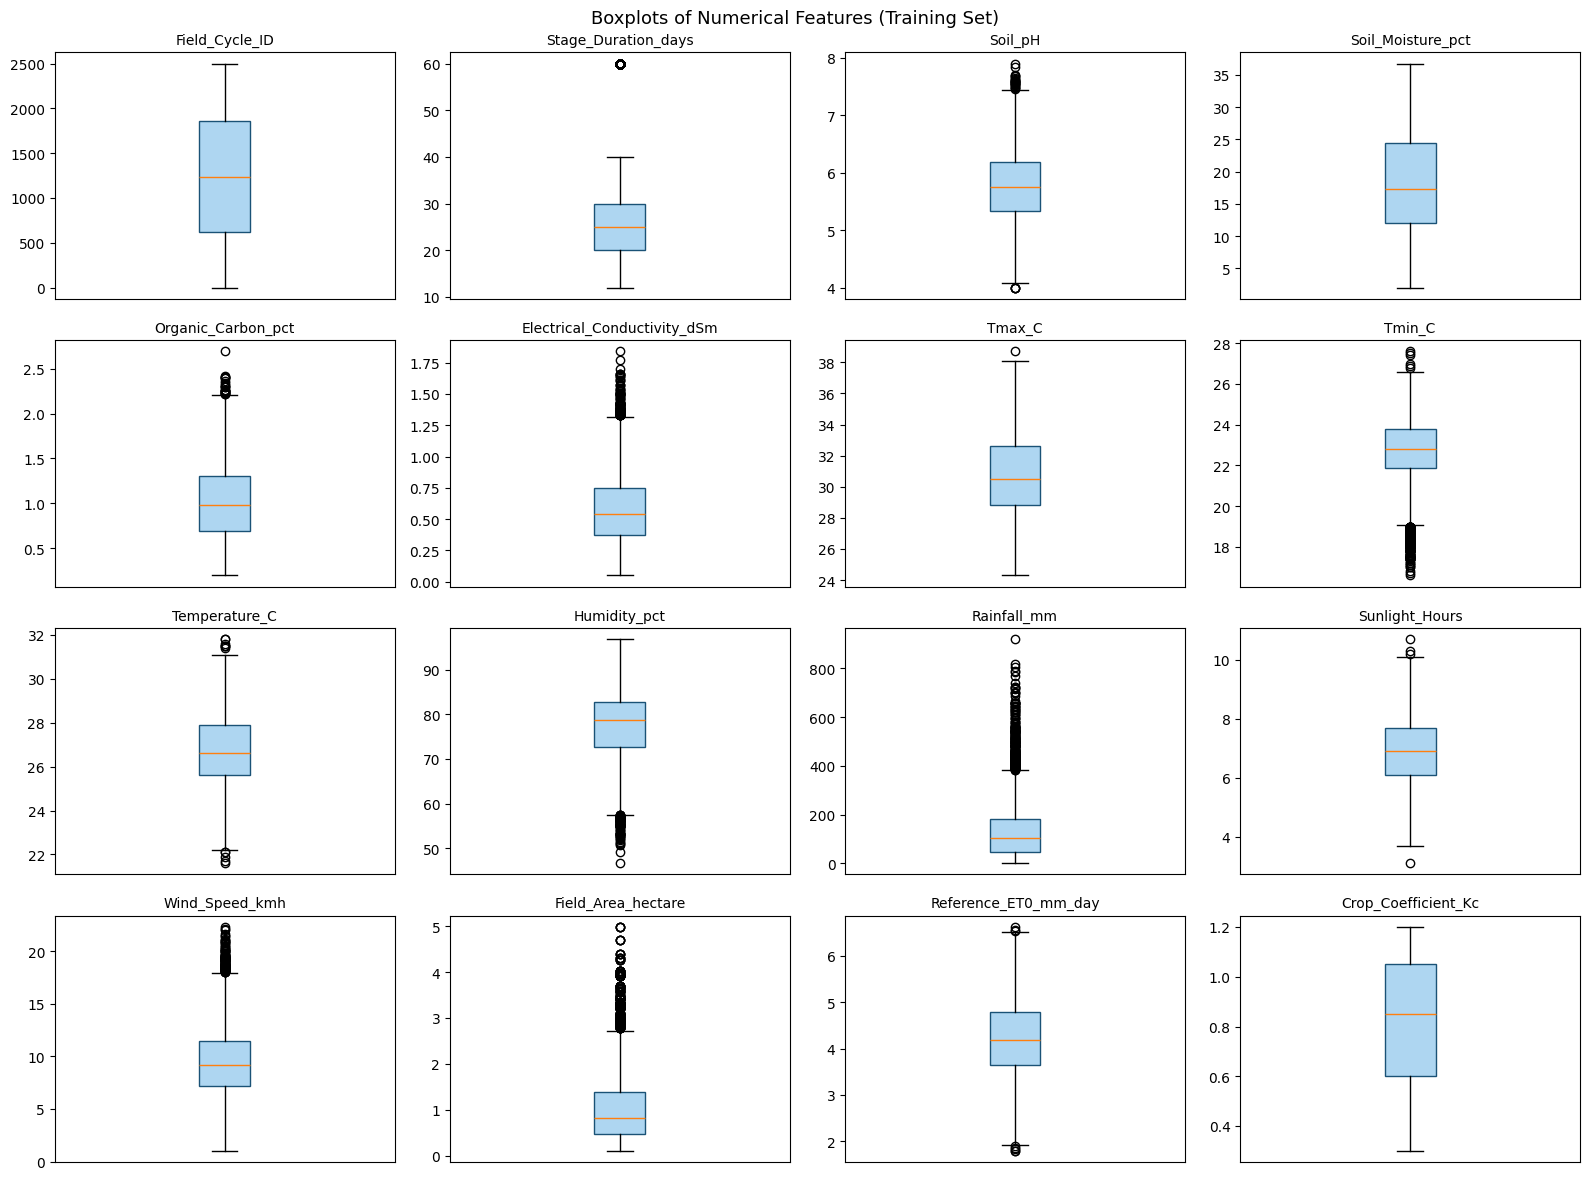

In [17]:
# ── Boxplots for visual outlier detection ──────────────────────────────────
# FIX (NEW STEP): Boxplots were missing in the original notebook
n_cols = 4
n_rows = (len(quan) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quan):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#1A5276'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
def OutlierDetector(Quan, descriptive_df, data_df):
    """
    Identifies low and high outliers, returning master tables with columns organized as:
    column_name -> outlier_count -> outlier_% -> threshold -> outlier_range.
    """
    low_summary_data = []
    high_summary_data = []
    LesserOut = []
    GreaterOut = []
    total_rows = len(data_df)
    
    for columnName in Quan:
        lesser_threshold = descriptive_df.loc["Lesser", columnName]
        greater_threshold = descriptive_df.loc["Greater", columnName]
        
        # 1. Process Low Outliers
        low_vals = data_df[data_df[columnName] < lesser_threshold][columnName].tolist()
        if len(low_vals) > 0:
            LesserOut.append(columnName)
            low_min, low_max = min(low_vals), max(low_vals)
            range_str = f"[{low_min}]" if low_min == low_max else f"[{low_min} to {low_max}]"
            
            low_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(low_vals),
                "outlier_%": f"{(len(low_vals) / total_rows) * 100:.2f}%",
                "lesser_threshold": lesser_threshold,
                "outlier_range": range_str
            })
            
        # 2. Process High Outliers
        high_vals = data_df[data_df[columnName] > greater_threshold][columnName].tolist()
        if len(high_vals) > 0:
            GreaterOut.append(columnName)
            high_min, high_max = min(high_vals), max(high_vals)
            range_str = f"[{high_min}]" if high_min == high_max else f"[{high_min} to {high_max}]"
            
            high_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(high_vals),
                "outlier_%": f"{(len(high_vals) / total_rows) * 100:.2f}%",
                "greater_threshold": greater_threshold,
                "outlier_range": range_str
            })
            
    df_low = pd.DataFrame(low_summary_data)
    df_high = pd.DataFrame(high_summary_data)
        
    return df_low, df_high, LesserOut, GreaterOut

In [19]:
df_low_summary, df_high_summary, lesser_outliers, greater_outliers = OutlierDetector(quan, descriptive, X_train)

print("📉 LOW OUTLIERS TABLE PROFILE:")
display(df_low_summary) 

print("\n📈 HIGH OUTLIERS TABLE PROFILE:")
display(df_high_summary)

📉 LOW OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,lesser_threshold,outlier_range
0,Soil_pH,4,0.05%,4.055,[4.0]
1,Tmin_C,240,3.00%,19.050,[16.6 to 19.0]
2,Temperature_C,5,0.06%,22.150,[21.6 to 22.1]
3,Humidity_pct,83,1.04%,57.450,[46.7 to 57.4]
4,Sunlight_Hours,1,0.01%,3.700,[3.1]
5,Reference_ET0_mm_day,5,0.06%,1.900,[1.79 to 1.9]



📈 HIGH OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,greater_threshold,outlier_range
0,Stage_Duration_days,306,3.82%,45.00000,[60]
1,Soil_pH,23,0.29%,7.45500,[7.46 to 7.9]
2,Organic_Carbon_pct,23,0.29%,2.21500,[2.22 to 2.69]
3,Electrical_Conductivity_dSm,106,1.32%,1.32000,[1.33 to 1.84]
4,Tmax_C,1,0.01%,38.30000,[38.7]
5,Tmin_C,6,0.07%,26.65000,[26.8 to 27.6]
6,Temperature_C,7,0.09%,31.35000,[31.4 to 31.8]
7,Rainfall_mm,290,3.62%,384.41250,[384.7 to 920.4]
8,Sunlight_Hours,3,0.04%,10.10000,[10.2 to 10.7]
9,Wind_Speed_kmh,105,1.31%,17.95000,[18.0 to 22.3]


# We have outliers in our dataset, but we will not remove them. These extreme values accurately represent real-world climate variations and severe weather conditions that are entirely plausible in a real-time scenario.

In [20]:
# Check skewness for all numerical features
skewness = X_train[quan].skew().sort_values(ascending=False)
print("Skewness of Numerical Features:\n", skewness)

Skewness of Numerical Features:
 Rainfall_mm                    1.521708
Field_Area_hectare             1.437137
Stage_Duration_days            1.306003
Electrical_Conductivity_dSm    0.576827
Wind_Speed_kmh                 0.524010
Soil_Moisture_pct              0.438857
Organic_Carbon_pct             0.382661
Tmax_C                         0.279310
Soil_pH                        0.142257
Sunlight_Hours                 0.128731
Temperature_C                  0.111458
Reference_ET0_mm_day           0.014535
Field_Cycle_ID                 0.011566
Crop_Coefficient_Kc           -0.423666
Humidity_pct                  -0.631520
Tmin_C                        -0.649567
dtype: float64


In [21]:
# Print frequency distribution for categorical columns
for col in qual:
    print(f"=== Distribution for {col} ===")
    
    # Calculate counts and percentages
    counts = X_train[col].value_counts()
    percentages = X_train[col].value_counts(normalize=True) * 100
    
    # Combine into a clean summary table
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary, "\n")


=== Distribution for Climate_Zone ===
              Count  Percentage (%)
Climate_Zone                       
Dry            3784            47.3
Wet            2920            36.5
Intermediate   1296            16.2 

=== Distribution for Season ===
        Count  Percentage (%)
Season                       
Maha     4120            51.5
Yala     3880            48.5 

=== Distribution for Crop_Type ===
              Count  Percentage (%)
Crop_Type                          
Green Gram     1432           17.90
Big Onion      1420           17.75
Paddy (Rice)   1352           16.90
Maize          1352           16.90
Chili          1224           15.30
Tomato         1220           15.25 

=== Distribution for Crop_Growth_Stage ===
                   Count  Percentage (%)
Crop_Growth_Stage                       
Initial             2000            25.0
Development         2000            25.0
Mid-season          2000            25.0
Late-season         2000            25.0 

=== Distri

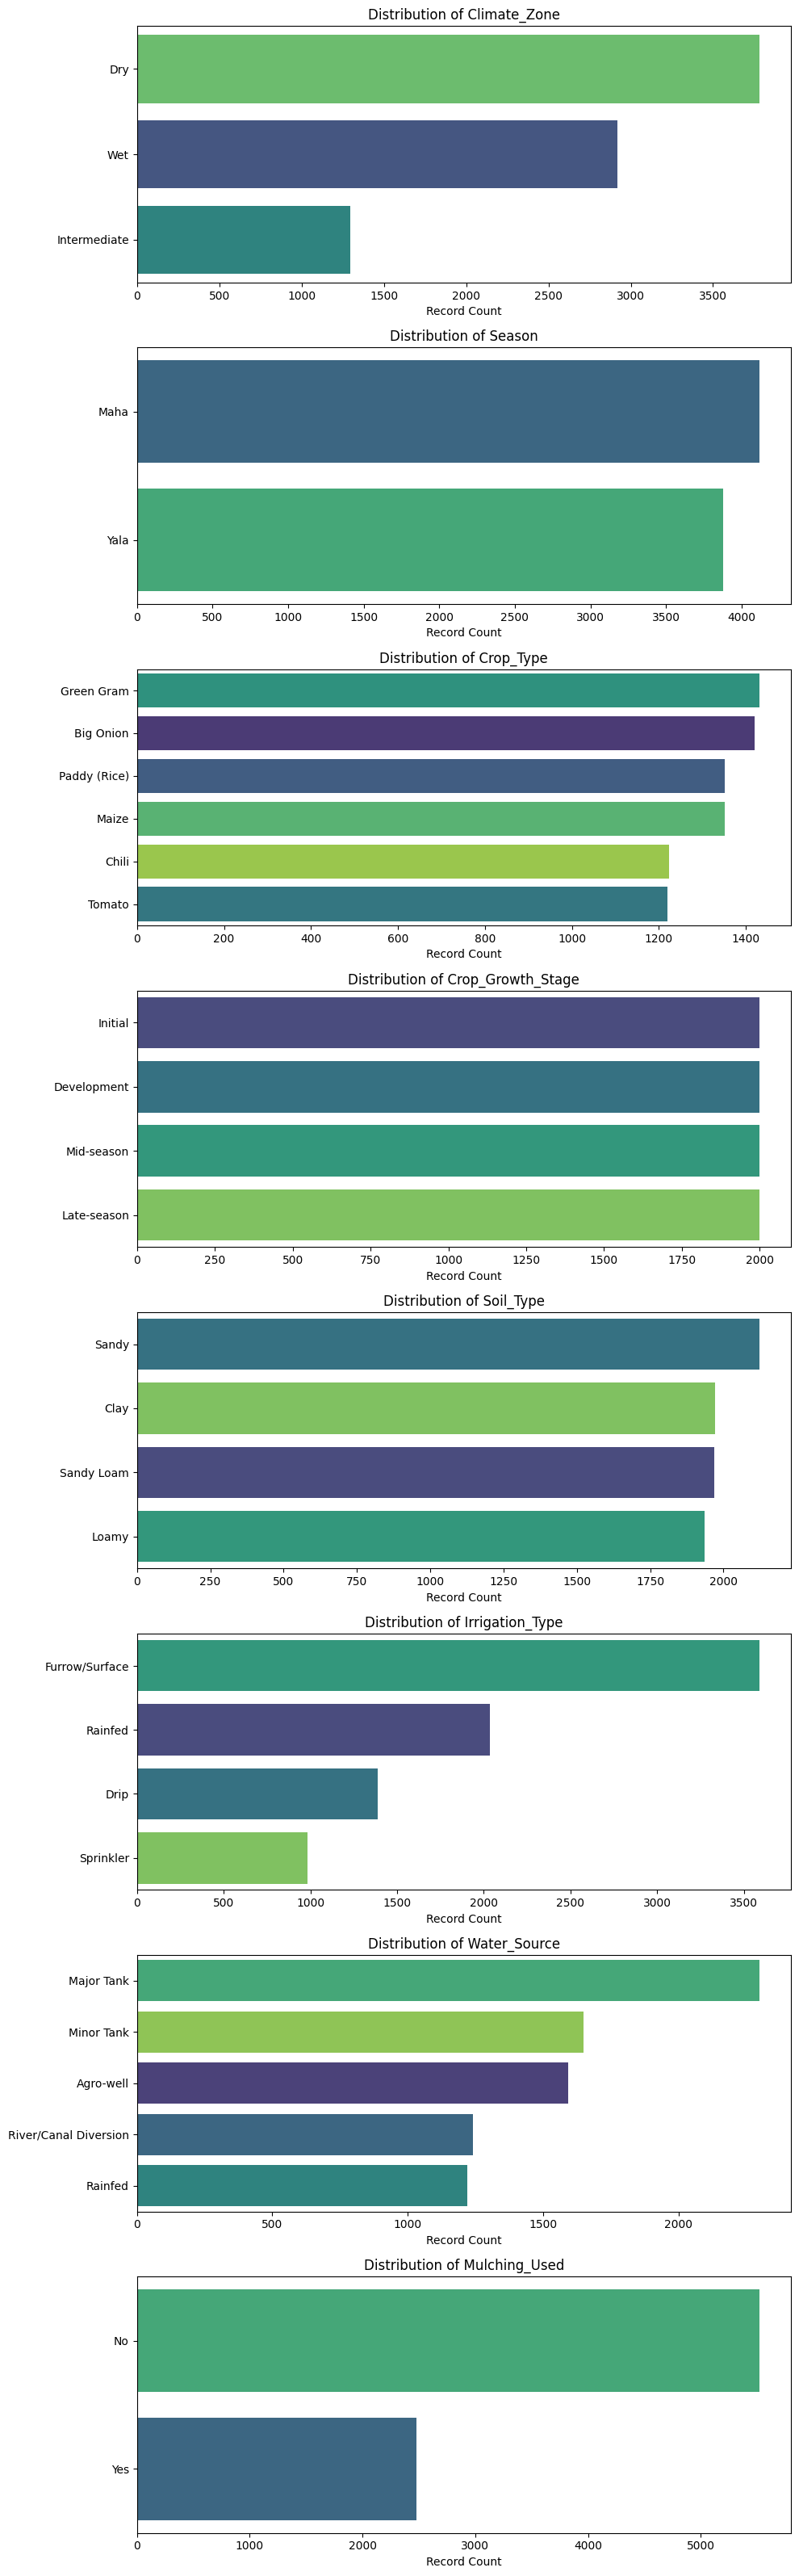

In [22]:
num_cols = len(qual)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 4 * num_cols))

# If there is only 1 categorical column, convert axes to an array to prevent errors
if num_cols == 1:
    axes = [axes]

# Plot a countplot for each categorical feature
for i, col in enumerate(qual):
    # Added hue=col and legend=False to fix the deprecation warning
    sns.countplot(
        data=X_train, 
        y=col, 
        ax=axes[i], 
        order=X_train[col].value_counts().index, 
        palette="viridis",
        hue=col,
        legend=False
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Record Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [23]:
X_train_clean=X_train.copy()
X_test_clean=X_test.copy()

# The Encoding (Categorical ----> Numarical)

In [24]:
from sklearn.preprocessing import OneHotEncoder

X_train_encoded = X_train_clean.copy()
X_test_encoded  = X_test_clean.copy()

# here we find the categorical features as bianry and multiple class in X_train_encoded
#====================================================================================
text_columns = [
    col for col in X_train_encoded.select_dtypes(include=['object', 'category']).columns 
    if not col.endswith('_is_missing')
]

binary_cols = [col for col in text_columns if X_train_encoded[col].nunique() <= 2]
multiclass_cols = [col for col in text_columns if X_train_encoded[col].nunique() > 2]

print("=== Encoding Feature Categorization ===")
print(f"🔹 Binary features mapped ({len(binary_cols)})")
print(f"🔹 Multi-class features mapped ({len(multiclass_cols)})\n")
# ====================================================================================


# encoding our binary categorical features
# ====================================================================================
if binary_cols:
    for col in binary_cols:
        # Cast to standard string arrays and read the unique elements present in the training set
        train_categories = X_train_encoded[col].astype(str).unique()
        
        # Build an explicit, clean 0/1 integer index mapping dictionary layout
        binary_map = {category_name: index for index, category_name in enumerate(train_categories[:2])}
        
        # Apply mapping across columns simultaneously via native vectorized math.
        # Unknown values in test split are safely caught using .fillna(0) to prevent rogue negative coordinates
        X_train_encoded[col] = X_train_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
        X_test_encoded[col]  = X_test_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
# ====================================================================================


# Here we are encoding the multi class categorical columns
# ====================================================================================
if multiclass_cols:
    # Initialize encoder. handle_unknown='ignore' ensures any brand-new unseen test categories are silently dropped
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    
    # Fit on training data and transform arrays via C-speed matrix operations
    train_ohe_array = ohe.fit_transform(X_train_encoded[multiclass_cols].astype(str))
    test_ohe_array  = ohe.transform(X_test_encoded[multiclass_cols].astype(str))
    
    # Generate human-readable new feature names (e.g., 'feature_category')
    new_column_names = ohe.get_feature_names_out(multiclass_cols)
    
    # Package matrices back into beautifully structured dataframes, keeping original index numbers aligned
    train_ohe_df = pd.DataFrame(train_ohe_array, columns=new_column_names, index=X_train_encoded.index)
    test_ohe_df  = pd.DataFrame(test_ohe_array,  columns=new_column_names, index=X_test_encoded.index)
    
    # Clean drop old original text string variables and append the newly created binary dummy columns
    X_train_encoded = pd.concat([X_train_encoded.drop(columns=multiclass_cols), train_ohe_df], axis=1)
    X_test_encoded  = pd.concat([X_test_encoded.drop(columns=multiclass_cols),  test_ohe_df],  axis=1)
# ====================================================================================

=== Encoding Feature Categorization ===
🔹 Binary features mapped (2)
🔹 Multi-class features mapped (6)



In [25]:
X_train_encoded.head()

,Field_Cycle_ID,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
0,0,0,15,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,0.92,0,3.77,0.70,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
1,0,0,25,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,0.92,0,3.87,0.90,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
2,0,0,35,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,0.92,0,2.79,1.05,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0
3,0,0,20,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,0.92,0,3.09,0.75,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0
4,1,0,20,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,1.63,1,4.43,1.05,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0


# Features Scalling

In [26]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler instance
scaler = StandardScaler()

# 2. FIT & TRANSFORM: Training split conversion
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded), 
    columns=X_train_encoded.columns, 
    index=X_train_encoded.index
)

# 3. TRANSFORM ONLY: Test split conversion (Prevents Data Leakage)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded), 
    columns=X_test_encoded.columns, 
    index=X_test_encoded.index
)

In [27]:
X_train_scaled.head()

,Field_Cycle_ID,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
0,-1.718461,-0.970437,-1.047150,0.309652,-0.360778,-0.299636,-0.398385,-0.801487,-0.049268,-0.604797,1.080585,-0.213397,-0.456436,-1.295306,-0.127311,-1.493659,-0.555177,-0.516221,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,-0.577350,1.732051,-0.577350,-0.577350,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
1,-1.718461,-0.970437,-0.073793,0.011882,0.039347,1.033992,-0.538801,-0.639180,-0.176086,-0.545860,0.264664,0.320452,-1.074344,-0.430770,-0.127311,-1.493659,-0.429050,0.272542,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,1.732051,-0.577350,-0.577350,-0.577350,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
2,-1.718461,-0.970437,0.899564,0.226938,0.087847,0.064081,-0.714320,-1.450715,0.267774,-0.958420,1.080585,-0.219553,-0.897799,-1.295306,-0.127311,-1.493659,-1.791227,0.864115,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,-0.577350,-0.577350,-0.577350,1.732051,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
3,-1.718461,-0.970437,-0.560471,0.144224,-0.078266,-1.148308,-0.468593,-1.085524,0.014140,-0.781608,0.948985,-0.146556,-0.632981,-0.338141,-0.127311,-1.493659,-1.412844,-0.319030,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,-0.577350,-0.577350,1.732051,-0.577350,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
4,-1.717080,-0.970437,-0.560471,-1.675481,-1.091914,-1.439281,-0.257970,-0.598603,-1.507665,-1.135231,0.396264,-0.237143,-0.986071,0.063250,0.846203,0.669497,0.277265,0.864115,-0.947382,2.274388,-0.758158,-0.464549,-0.425015,-0.466933,-0.450965,2.217467,-0.424195,-0.577350,1.732051,-0.577350,-0.577350,-0.571962,-0.565032,1.663273,-0.571192,2.182588,-0.902708,-0.584279,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829


# Here we create a base line for the model using dummy regressor

In [28]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the baseline regressor (always predicts the mean target value)
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_train, y_train)

# 2. Predict on the test set
y_dummy_pred = dummy_reg.predict(X_test)

# 3. Evaluate the benchmark
print("=== Baseline (DummyRegressor — Mean Target Value) ===")
print(f"MAE      : {mean_absolute_error(y_test, y_dummy_pred):.2f} mm")
print(f"R² Score : {r2_score(y_test, y_dummy_pred):.4f}")
print("\nAny real model MUST achieve a LOWER MAE and a HIGHER R² score than this baseline.")

=== Baseline (DummyRegressor — Mean Target Value) ===
MAE      : 29.61 mm
R² Score : -0.0008

Any real model MUST achieve a LOWER MAE and a HIGHER R² score than this baseline.


# Checking the correlation between features to avoid the multicollinearity

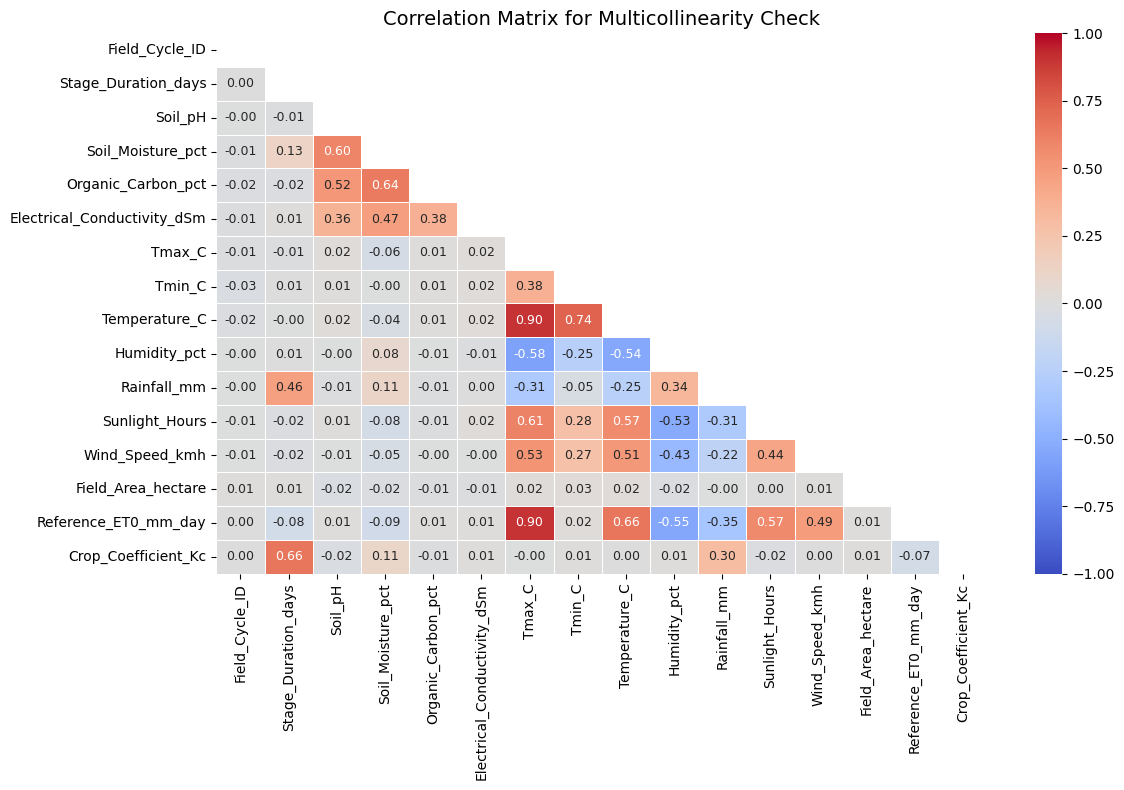


--- Variance Inflation Factor (VIF) Scores ---
                        Feature          VIF
0                 Temperature_C  2258.097575
1                        Tmax_C  1206.443993
2                        Tmin_C   492.318343
3          Reference_ET0_mm_day    18.763827
4             Soil_Moisture_pct     2.338666
5           Stage_Duration_days     2.201417
6           Crop_Coefficient_Kc     1.822846
7                Sunlight_Hours     1.811463
8            Organic_Carbon_pct     1.809919
9                  Humidity_pct     1.771432
10                      Soil_pH     1.679471
11                  Rainfall_mm     1.575809
12               Wind_Speed_kmh     1.501711
13  Electrical_Conductivity_dSm     1.322539
14           Field_Area_hectare     1.002791
15               Field_Cycle_ID     1.001262


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure we ONLY check multicollinearity on numerical features
# (Using encoded categorical variables will break VIF or cause infinite scores)
X_train_numerical = X_train_scaled[quan]

# ==========================================
# 2. METHOD A: VISUAL CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(12, 8))
corr_matrix = X_train_numerical.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix for Multicollinearity Check', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
# ==========================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_numerical.columns

# Calculate VIF score safely for each numerical feature
vif_data["VIF"] = [
    variance_inflation_factor(X_train_numerical.values, i) 
    for i in range(X_train_numerical.shape[1])
]

# Sort features by VIF score in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Variance Inflation Factor (VIF) Scores ---")
print(vif_data)

--- Top 10 Most Important Features ---
                 Feature  Importance
0    Crop_Coefficient_Kc    0.263354
1            Rainfall_mm    0.240910
2    Stage_Duration_days    0.157413
3          Temperature_C    0.129647
4                 Tmax_C    0.075801
5   Reference_ET0_mm_day    0.041038
6        Crop_Type_Chili    0.013623
7                 Season    0.011893
8           Humidity_pct    0.011550
9      Soil_Moisture_pct    0.007302
10        Sunlight_Hours    0.004571
11    Organic_Carbon_pct    0.004479


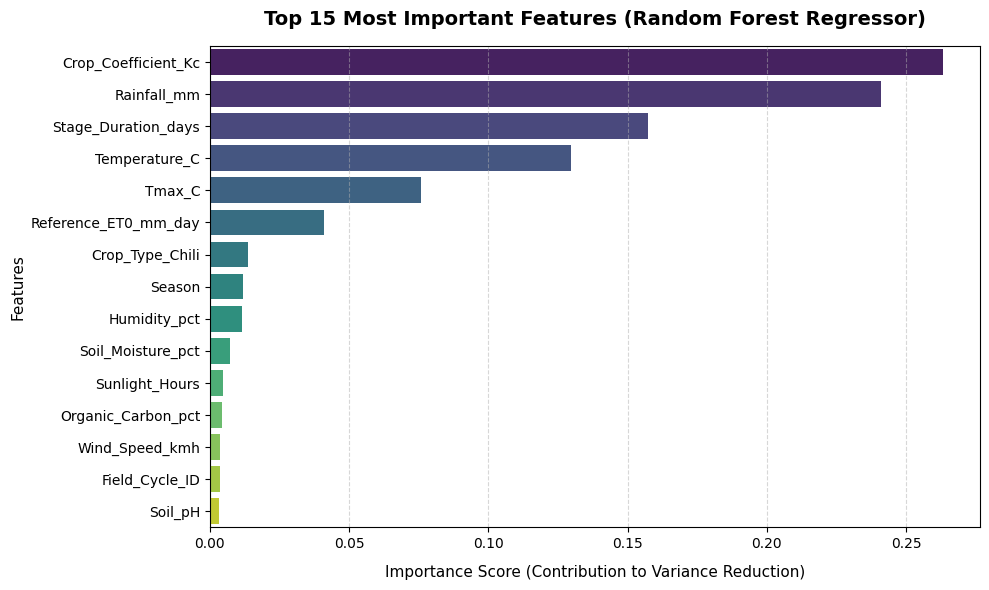

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. INITIALIZE AND TRAIN THE MODEL 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. EXTRACT SCORES AND PAIR THEM WITH COLUMN NAMES
importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 10 Most Important Features ---")
print(importance_df.head(12))

# =====================================================================
# 3. PLOT THE TOP 10 FEATURE IMPORTANCE (Optimized for a Clean Output)
# =====================================================================
# Select only the top 10 rows to prevent the chart from becoming overcrowded
top_10_importance = importance_df.head(15)

# Set a wider, cleaner figure size optimized for 10 bars
plt.figure(figsize=(10, 6))

# Generate the barplot using only the top 10 features
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_10_importance, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# Add clean labels, a larger title, and clear gridlines for readability
plt.title('Top 15 Most Important Features (Random Forest Regressor)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Contribution to Variance Reduction)', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5) # Adds a soft background grid for easier tracking

plt.tight_layout()
plt.show()

# We droped the featues (Tempreature_C and Tmax_C) to avoid Multicollinearity based on Correlation matrix, VIF Score and Featute Importance

In [31]:
X_train_final = X_train_scaled.drop(columns=['Temperature_C', 'Tmax_C'])

# 2. Mirror the exact same step on the testing data
X_test_final = X_test_scaled.drop(columns=['Temperature_C', 'Tmax_C'])

# --- Quick verification check ---
print(f"Cleaned Data Shapes -> Train: {X_train_final.shape} | Test: {X_test_final.shape}")

Cleaned Data Shapes -> Train: (8000, 42) | Test: (2000, 42)


In [32]:
X_train_final

,Field_Cycle_ID,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmin_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
0,-1.718461,-0.970437,-1.047150,0.309652,-0.360778,-0.299636,-0.398385,-0.049268,1.080585,-0.213397,-0.456436,-1.295306,-0.127311,-1.493659,-0.555177,-0.516221,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,-0.577350,1.732051,-0.577350,-0.577350,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
1,-1.718461,-0.970437,-0.073793,0.011882,0.039347,1.033992,-0.538801,-0.176086,0.264664,0.320452,-1.074344,-0.430770,-0.127311,-1.493659,-0.429050,0.272542,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,1.732051,-0.577350,-0.577350,-0.577350,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
2,-1.718461,-0.970437,0.899564,0.226938,0.087847,0.064081,-0.714320,0.267774,1.080585,-0.219553,-0.897799,-1.295306,-0.127311,-1.493659,-1.791227,0.864115,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,-0.577350,-0.577350,-0.577350,1.732051,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
3,-1.718461,-0.970437,-0.560471,0.144224,-0.078266,-1.148308,-0.468593,0.014140,0.948985,-0.146556,-0.632981,-0.338141,-0.127311,-1.493659,-1.412844,-0.319030,-0.947382,-0.439679,1.318987,2.152627,-0.425015,-0.466933,-0.450965,-0.450965,-0.424195,-0.577350,-0.577350,1.732051,-0.577350,-0.571962,-0.565032,-0.601224,1.750726,-0.458172,-0.902708,1.711512,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
4,-1.717080,-0.970437,-0.560471,-1.675481,-1.091914,-1.439281,-0.257970,-1.507665,0.396264,-0.237143,-0.986071,0.063250,0.846203,0.669497,0.277265,0.864115,-0.947382,2.274388,-0.758158,-0.464549,-0.425015,-0.466933,-0.450965,2.217467,-0.424195,-0.577350,1.732051,-0.577350,-0.577350,-0.571962,-0.565032,1.663273,-0.571192,2.182588,-0.902708,-0.584279,-0.374501,2.006272,-0.635223,-0.509358,-0.424195,-0.42829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,1.727151,-0.970437,0.412886,-0.699457,-0.676027,-1.560520,0.093069,0.458000,0.159384,-0.004958,-2.310161,-1.357058,-0.031331,0.669497,-1.501134,0.272542,-0.947382,-0.439679,1.318987,-0.464549,2.352859,-0.466933,-0.450965,-0.450965,-0.424195,-0.577350,-0.577350,1.732051,-0.577350,-0.571962,-0.565032,1.663273,-0.571192,2.182588,-0.902708,-0.584279,-0.374501,-0.498437,1.574249,-0.509358,-0.424195,-0.42829
9996,1.731292,1.030464,-0.560471,-1.377711,-0.988852,-0.808839,-1.065359,1.282311,-1.656697,-0.517699,2.015198,-0.986543,-0.579789,0.669497,0.794388,0.864115,1.055540,-0.439679,-0.758158,-0.464549,-0.425015,-0.466933,-0.450965,2.217467,-0.424195,-0.577350,1.732051,-0.577350,-0.577350,-0.571962,-0.565032,1.663273,-0.571192,2.182588,-0.902708,-0.584279,-0.374501,-0.498437,-0.635223,1.963255,-0.424195,-0.42829
9997,1.731292,1.030464,0.412886,-1.576224,-0.676027,-0.954326,-1.135567,1.789580,-1.919897,-1.139496,1.750380,1.946703

# Finding the best features using RFECV using GroupKFold

--- Top 15 Most Important Features (Averaged across GroupKFold) ---
                         Feature  Importance
0            Crop_Coefficient_Kc    0.254521
1                    Rainfall_mm    0.242335
2            Stage_Duration_days    0.165173
3                  Temperature_C    0.134518
4                         Tmax_C    0.067098
5           Reference_ET0_mm_day    0.042978
6                Crop_Type_Chili    0.012283
7                   Humidity_pct    0.011523
8                         Season    0.011070
9              Soil_Moisture_pct    0.007314
10                Sunlight_Hours    0.005185
11  Crop_Growth_Stage_Mid-season    0.004328
12            Organic_Carbon_pct    0.004131
13                Wind_Speed_kmh    0.004127
14                        Tmin_C    0.003941


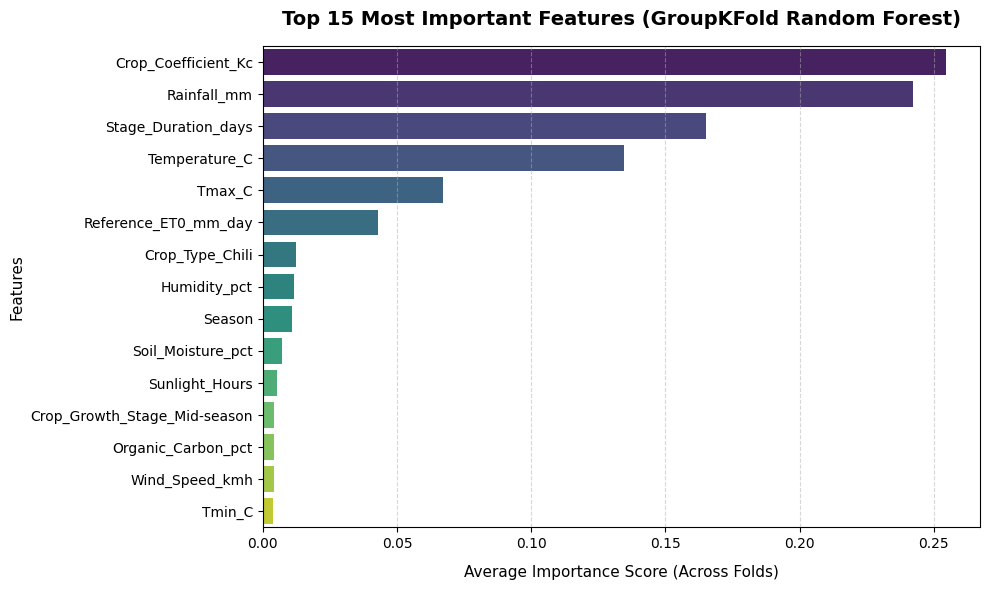

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold

# 1. INITIALIZE GROUPKFOLD AND ARRAYS
# 'n_splits=5' means your model will train and evaluate 5 different times
gkf = GroupKFold(n_splits=5)

# Create an array to accumulate feature importances across all folds
# (Assumes X_train_scaled is a pandas DataFrame to extract column names)
feature_names = X_train_scaled.columns
importance_scores = np.zeros(len(feature_names))

# 2. RUN THE CROSS-VALIDATION LOOP
# 'df_raw' or your original dataframe containing the 'Field_Cycle_ID' column
groups = df.loc[X_train_scaled.index, 'Field_Cycle_ID'] 

for train_idx, val_idx in gkf.split(X_train_scaled, y_train, groups=groups):
    # Split the data for the current fold
    X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Train the model on this fold
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_tr, y_tr)
    
    # Add the current fold's importance scores to our running total
    importance_scores += rf_model.feature_importances_

# Calculate the average importance score across all 5 folds
average_importance = importance_scores / gkf.n_splits

# 3. PAIR THE AVERAGE SCORES WITH COLUMN NAMES
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': average_importance
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 15 Most Important Features (Averaged across GroupKFold) ---")
print(importance_df.head(15))

# =====================================================================
# 4. PLOT THE TOP 15 FEATURE IMPORTANCE
# =====================================================================
top_15_importance = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_15_importance, 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Top 15 Most Important Features (GroupKFold Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Importance Score (Across Folds)', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Here, we analyze the best features and rank them based on feature importance to pick only a few, making the model easy to use and  cost-effective

In [34]:
from sklearn.ensemble import RandomForestRegressor

# 1. CRITICAL FIX: Filter BOTH train and test sets to maintain shape alignment
X_train_pre = X_train_final[selected_feats]
X_test_pre  = X_test_final[selected_feats]  # Added: Prevents ValueError at prediction time

# 2. Re-fit your TRUE production model architecture on the filtered features
# (We use the regressor now that we've cleared out the fast selection proxies)
production_engine = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
production_engine.fit(X_train_pre, y_train)

# 3. Extract and sort the actual mathematical importances based on variance reduction
rankings = pd.Series(production_engine.feature_importances_, index=X_train_pre.columns)
limited_features = rankings.nlargest(5).index.tolist()

print("--- 🌾 True Random Forest Regressor Rankings ---")
print(rankings.sort_values(ascending=False))

print(f"\n✅ Use these 5 features for your cost-effective deployment pipeline:\n{limited_features}")


NameError: name 'selected_feats' is not defined

In [ ]:
limited_features

# Here, we create a new dataframe that contains only the limited selected features

In [ ]:
# The elite, dynamic pandas execution way
X_train_selected = X_train_final[limited_features]
X_test_selected  = X_test_final[limited_features]

print(f"\nFinal Ready Shapes ➔ Train: {X_train_selected.shape} | Test: {X_test_selected.shape}\n")

In [ ]:
print("--- Features Matrix Columns Verification ---")
print(list(X_train_selected.columns))
print()

# Multi-Model Performance Benchmarking

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Continuous cross-validation setup (No stratification on floats!)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Rebuilt Model Suite for Continuous Net Irrigation Predictions
REGRESSION_MODELS = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=42),
    "KNN Regressor":       KNeighborsRegressor(n_neighbors=5),
    "SVM Regressor (RBF)": SVR(kernel="rbf", C=1.0),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42, n_estimators=100),
}

results = []
for name, model in REGRESSION_MODELS.items():
    
    # 3. Step A: Cross-Validation using Negative MAE on your SELECTED 5-feature training matrix
    # FIXED: Replaced X_train_pre with X_train_selected
    cv_scores = cross_val_score(model, X_train_selected, y_train, cv=cv5, scoring='neg_mean_absolute_error', n_jobs=-1)
    mean_cv_mae = -cv_scores.mean()
    
    # 4. Step B: Train ONCE on full 5-feature training data to predict on the 5-feature test set
    # FIXED: Replaced X_train_pre/X_test_pre with X_train_selected/X_test_selected
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    # 5. Calculate exact performance metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    # 6. Collect all metrics for this model row
    results.append({
        "Model": name,
        "CV MAE (Train)": mean_cv_mae, 
        "Test MAE (mm)":  mae,
        "Test RMSE (mm)": rmse,
        "Test R² Score":  r2
    })

# 7. Turn into a DataFrame and rank by the lowest Cross-Validation error
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="CV MAE (Train)", ascending=True).reset_index(drop=True)

# 8. Format the final output table for clean presentation
df_results["CV MAE (Train)"] = df_results["CV MAE (Train)"].map(lambda x: f"{x:.2f} mm")
df_results["Test MAE (mm)"]  = df_results["Test MAE (mm)"].map(lambda x: f"{x:.2f} mm")
df_results["Test RMSE (mm)"] = df_results["Test RMSE (mm)"].map(lambda x: f"{x:.2f} mm")
df_results["Test R² Score"]  = df_results["Test R² Score"].map(lambda x: f"{x:.4f}")

print("\n📊 PRODUCTION MODEL BENCHMARK TABLE (Ranked by Lowest CV MAE)")
print("="*85)
display(df_results)

# Hyperparameter Tuning: Optimizing the Random Forest Model

In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.ensemble import RandomForestRegressor

# 1. Hyperparameter grid with explicit candidate lists
param_grid = {
    'n_estimators': [100, 200, 300],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2]
}

# 2. Group-aware cross-validation
cv_strategy = GroupKFold(n_splits=5)

# 3. Grid search setup
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# 4. Extract groups for the training rows
groups = df.loc[X_train_selected.index, 'Field_Cycle_ID']

# 5. Fit with groups
grid_search.fit(X_train_selected, y_train, groups=groups)

best_rf_model = grid_search.best_estimator_

print("--- 🎯 Hyperparameter Tuning Summary ---")
print(f"Best RF Parameters : {grid_search.best_params_}")
print(f"Best CV MAE        : {-grid_search.best_score_:.2f} mm")

# Final Model Evaluation & Diagnostic Plots

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. FIXED: Predict on your SELECTED test features to match y_test sample sizes
y_pred = best_rf_model.predict(X_test_selected)

# 2. Calculate Final Performance Metrics on Unseen Test Data
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print("🏆 FINAL TUNED REGRESSION MODEL REPORT")
print("=" * 55)
print(f"Final Mean Absolute Error (MAE) : {final_mae:.2f} mm")
print(f"Final Root Mean Squared Error   : {final_rmse:.2f} mm")
print(f"Final R² Score (Variance Match) : {final_r2:.4f}")
print("=" * 55)

# 3. Structural Evaluation Graphics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Prediction vs Actuals (Ideally a tight diagonal 45-degree line)
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#2563EB', edgecolors='k')
ideal_line = [min(y_test), max(y_test)]
axes[0].plot(ideal_line, ideal_line, 'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_ylabel('Predicted Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_title('Actual vs. Predicted Values', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot B: Residuals Distribution (Checks if errors are normally distributed around 0)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='#DC2626', ax=axes[1], bins=30)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Error (Actual - Predicted) [mm]', fontsize=11)
axes[1].set_title('Residuals Error Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


# Feature Impact Ranking

In [ ]:
importances = best_rf_model.feature_importances_

irrigation_importance_df = pd.DataFrame({
    'Feature': X_test_selected.columns,
    'Importance Score': importances,
    'Contribution': ['High Impact' if imp > 0.10 else 'Moderate/Low Impact' for imp in importances]
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

print("🌾 IRRIGATION FEATURE IMPORTANCE RANKING")
print("="*55)
display(irrigation_importance_df)

# Saving Production Model & Pipeline Assets for Deployment

In [ ]:
import os
import joblib

# 1. FIXED: Exporting the model, the feature schema, AND the vital scaler instance
joblib.dump(best_rf_model, 'sri_lanka_irrigation_model.joblib')
joblib.dump(scaler, 'irrigation_scaler.joblib') # Added: Keeps deployment inputs properly scaled
joblib.dump(limited_features, 'selected_features.joblib') 

# 2. Physical File Integrity Logs
asset_files = ['sri_lanka_irrigation_model.joblib', 'irrigation_scaler.joblib', 'selected_features.joblib']
print("📦 EXPORTING ALL 3 PRODUCTION ARTIFACTS...")
print("=" * 65)

for file_name in asset_files:
    if os.path.exists(file_name):
        size_kb = os.path.getsize(file_name) / 1024
        print(f"  • File Name: '{file_name:<32}' | File Size: {size_kb:.2f} KB")
    else:
        print(f"  🚨 ERROR: Failed to serialize file: '{file_name}'")
print("=" * 65)
print("✅ Done! All 3 files verified. Your deployment app is now structurally safe.")

# Pre-Deployment Safety Audit

In [ ]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import joblib

# Suppress scikit-learn's 1D array warning noise globally
warnings.filterwarnings('ignore', category=UserWarning, append=True)

def run_pre_deployment_checks(model_path, scaler_path, sample_X, sample_y):
    print("=" * 65)
    print("🌊 PRODUCTION-GRADE AGRICULTURAL MODEL INTEGRITY AUDIT")
    print("=" * 65)

    print("\n1. File existence check...")
    if os.path.exists(model_path) and os.path.exists(scaler_path):
        print(f"  [PASS] Both production model and scaler files found.")
    else:
        print("  [FAIL] Missing model or scaler asset files!"); return

    print("\n2. Loading check...")
    try:
        deployed_scaler = joblib.load(scaler_path)
        deployed_model = joblib.load(model_path)
        print("  [PASS] Model and Scaler successfully loaded into memory.")
    except Exception as e:
        print(f"  [FAIL] Deserialization failed: {e}"); return

    # =====================================================================
    # 3. FIXED: INTEGRATED PREDICTION LATENCY & BASELINE ALIGNMENT CHECK
    # =====================================================================
    print("\n3. Prediction latency check...")
    batch = sample_X.head(5)
    
    # FRESH BASELINE: Generate a live prediction in the notebook right now
    notebook_baseline_preds = best_rf_model.predict(batch)
    
    t0    = time.time()
    deployed_file_preds = deployed_model.predict(batch)
    ms    = (time.time() - t0) * 1000
    print(f"  [PASS] Prediction Latency: {ms:.2f} ms")
    
    # Check if the loaded file matches the active notebook model exactly
    if np.allclose(deployed_file_preds, notebook_baseline_preds, atol=1e-5):
        print("  [PASS] Saved model file output matches active notebook baseline exactly.")
    else:
        print(f"  [WARN] Prediction mismatch! The saved file does not match the active model instance."); return

    print("\n4. End-to-End Edge-Case Pipeline Stress Test...")
    try:
        all_original_features = list(deployed_scaler.feature_names_in_)
        extreme_field = pd.DataFrame([{col: 0.0 for col in all_original_features}])
        
        if 'Rainfall_mm' in extreme_field.columns:
            extreme_field['Rainfall_mm'] = 0.0            
        if 'Soil_Moisture_pct' in extreme_field.columns:
            extreme_field['Soil_Moisture_pct'] = 5.0      
        if 'Stage_Duration_days' in extreme_field.columns:
            extreme_field['Stage_Duration_days'] = 60.0   

        extreme_field = extreme_field[all_original_features]
        
        scaled_extreme = pd.DataFrame(
            deployed_scaler.transform(extreme_field), 
            columns=all_original_features, 
            index=extreme_field.index
        )
        
        extreme_features = scaled_extreme[list(sample_X.columns)]
        net_requirement_prediction = deployed_model.predict(extreme_features)[0] # Extract scalar float
        
        print(f"  • Raw Agricultural Data successfully Scaled ➔ Model Scored.")
        print(f"  • Predicted Net Irrigation Requirement: {net_requirement_prediction:.2f} mm")
        print("  [PASS]" if net_requirement_prediction > 0 else "  [WARN] Unexpectedly low or zero water requirement for a severe drought case.")
            
    except Exception as e:
        print(f"  [FAIL] Deployment pipeline crashed! Error: {e}")
        return

    print("\n" + "=" * 65)
    print("🎉 DEPLOYMENT AUDIT COMPLETE: PIPELINE IS SECURE FOR PRODUCTION")
    print("=" * 65)

# Run the complete framework using your actual variable environments
run_pre_deployment_checks(
    'sri_lanka_irrigation_model.joblib', 
    'irrigation_scaler.joblib', 
    X_test_selected, 
    y_test
)
